In [1]:
# ---- imports & options
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 50)
pd.set_option("display.width", 140)
pd.options.mode.copy_on_write = True

# Warnings: keep noise down
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# ---- load data produced by your script
turns = pd.read_csv("results/turns_long.csv")
tok   = pd.read_csv("results/tokens_with_meta.csv")

# standardize some columns to lower-case strings for matching
for df in (turns, tok):
    for c in ["university","spanish_level","gender","mother_tongue","nationality","token","lemma"]:
        if c in df.columns:
            df[c] = df[c].astype(str).str.strip()

# a lowercase cache for tokens
tok["token_lc"] = tok["token"].str.lower()
turns["normalized_lc"] = turns["normalized_text"].astype(str).str.lower()

print(turns.shape, tok.shape)
turns.head(2), tok.head(2)


(3953, 33) (97007, 18)


(   doc_id speaker  turn_id                                           raw_text                                    normalized_text  \
 0     101       A        0                                  ¿qué edad tienes?                                  ¿qué edad tienes?   
 1     101       B        1  ¡Ah sí! Es que ee*eee eso es una cosa sí que y...  eee eso es una cosa sí que yo no soy tan joven...   
 
    token_count  type_count       ttr  root_ttr  maas  ...  question_marks  age  gender  mother_tongue  spanish_level  nationality  \
 0            3           3  1.000000  1.732051   0.0  ...               1    2       F             fr             B2           BE   
 1           38          25  0.657895  4.055536   0.0  ...               0    3       F             sl             C1           SI   
 
                    university  nationality_A  nationality_B                                      normalized_lc  
 0  Vrije Universiteit Brussel             BE             SI                     

In [2]:
# Your canonical list (as you gave it) — we’ll auto-separate into singles vs MWEs
canonical_list = [
"a lo mejor","a ver","además","afortunadamente","al fin y al cabo","al menos","al mismo tiempo","apenas","aun así",
"básicamente","bien","bueno","claramente","claro","completamente","concretamente","de acuerdo","de alguna forma",
"de alguna manera","de hecho","de todas formas","de todos modos","de verdad","definitivamente","desde luego","digamos",
"efectivamente","en cambio","en ese sentido","en fin","en general","en particular","en realidad","en verdad","entonces",
"es decir","eso sí","especialmente","exactamente","exacto","fíjate","generalmente","hasta","hombre","igual","incluso",
"justamente","justo","la verdad","más bien","más o menos","menos mal","mira","nada","ni siquiera","¿no?","no sé","o sea",
"obviamente","oye","perdón","perdona","pero","por (lo) tanto","por cierto","por ejemplo","por el contrario","por eso",
"por lo menos","por supuesto","por un lado","por otro lado","por una parte","por otra parte","porque","prácticamente",
"precisamente","pues","pues bien","pues nada","pues sí","realmente","seguramente","seguro","sin embargo","sobre todo",
"solamente","solo","también","tampoco","total","totalmente","vale","vamos","vaya","(y) es que","ya"
]

# helpers for safer regex (lowercase; accents left as-is to match your text)
def wb(s):    # wrap with word boundaries
    return r"\b" + s + r"\b"

# Build a dictionary: canonical -> compiled regex (for MWEs searched in turns)
mwe_regex = {
    # Optional token cases & multiword exact phrases (lowercase)
    "a lo mejor": re.compile(wb(r"a\s+lo\s+mejor")),
    "al fin y al cabo": re.compile(wb(r"al\s+fin\s+y\s+al\s+cabo")),
    "al menos": re.compile(wb(r"al\s+menos")),
    "al mismo tiempo": re.compile(wb(r"al\s+mismo\s+tiempo")),
    "aun así": re.compile(wb(r"aun\s+así")),
    "de acuerdo": re.compile(wb(r"de\s+acuerdo")),
    "de alguna forma": re.compile(wb(r"de\s+alguna\s+forma")),
    "de alguna manera": re.compile(wb(r"de\s+alguna\s+manera")),
    "de hecho": re.compile(wb(r"de\s+hecho")),
    "de todas formas": re.compile(wb(r"de\s+todas\s+formas")),
    "de todos modos": re.compile(wb(r"de\s+todos\s+modos")),
    "de verdad": re.compile(wb(r"de\s+verdad")),
    "desde luego": re.compile(wb(r"desde\s+luego")),
    "en cambio": re.compile(wb(r"en\s+cambio")),
    "en ese sentido": re.compile(wb(r"en\s+ese\s+sentido")),
    "en fin": re.compile(wb(r"en\s+fin")),
    "en general": re.compile(wb(r"en\s+general")),
    "en particular": re.compile(wb(r"en\s+particular")),
    "en realidad": re.compile(wb(r"en\s+realidad")),
    "en verdad": re.compile(wb(r"en\s+verdad")),
    "es decir": re.compile(wb(r"es\s+decir")),
    "eso sí": re.compile(wb(r"eso\s+sí")),
    "la verdad": re.compile(wb(r"la\s+verdad")),
    "más bien": re.compile(wb(r"más\s+bien")),
    "más o menos": re.compile(wb(r"más\s+o\s+menos")),
    "menos mal": re.compile(wb(r"menos\s+mal")),
    "ni siquiera": re.compile(wb(r"ni\s+siquiera")),
    "no sé": re.compile(wb(r"no\s+sé")),
    "o sea": re.compile(wb(r"o\s+sea")),
    "por (lo) tanto": re.compile(wb(r"por\s+(lo\s+)?tanto")),
    "por cierto": re.compile(wb(r"por\s+cierto")),
    "por ejemplo": re.compile(wb(r"por\s+ejemplo")),
    "por el contrario": re.compile(wb(r"por\s+el\s+contrario")),
    "por eso": re.compile(wb(r"por\s+eso")),
    "por lo menos": re.compile(wb(r"por\s+lo\s+menos")),
    "por supuesto": re.compile(wb(r"por\s+supuesto")),
    "por un lado": re.compile(wb(r"por\s+un\s+lado")),
    "por otro lado": re.compile(wb(r"por\s+otro\s+lado")),
    "por una parte": re.compile(wb(r"por\s+una\s+parte")),
    "por otra parte": re.compile(wb(r"por\s+otra\s+parte")),
    "pues bien": re.compile(wb(r"pues\s+bien")),
    "pues nada": re.compile(wb(r"pues\s+nada")),
    "pues sí": re.compile(wb(r"pues\s+sí")),
    "sin embargo": re.compile(wb(r"sin\s+embargo")),
    "sobre todo": re.compile(wb(r"sobre\s+todo")),
    "(y) es que": re.compile(wb(r"(y\s+)?es\s+que")),  # optional y
    "¿no?": re.compile(r"¿\s*no\s*\?"),               # special punctuation
}

# Single tokens we’ll count in tokens.csv (lowercase string set)
single_tokens = {
    "además","afortunadamente","apenas","básicamente","bien","bueno","claramente","claro","completamente",
    "concretamente","definitivamente","digamos","efectivamente","especialmente","exactamente","exacto","fíjate",
    "generalmente","hasta","hombre","igual","incluso","justamente","justo","mira","nada","obviamente","oye",
    "perdón","perdona","pero","porque","prácticamente","precisamente","pues","realmente","seguramente","seguro",
    "solamente","solo","también","tampoco","total","totalmente","vale","vamos","vaya","ya","entonces","en fin",
    "a ver"
}
# sanity check: everything in canonical list is covered one way or another
covered = set(mwe_regex.keys()) | single_tokens
missing = [x for x in canonical_list if x not in covered]
missing  # ok if empty


[]

In [3]:
# totals per metadata cell for normalization
totals = (turns
          .groupby(["university","spanish_level","gender","mother_tongue"], observed=True)["token_count"]
          .sum()
          .rename("tokens_total")
          .reset_index())

# raw counts for single tokens
single_counts = (tok.loc[tok["token_lc"].isin(single_tokens)]
                 .groupby(["token_lc","university","spanish_level","gender","mother_tongue"], observed=True)
                 .size().rename("n")
                 .reset_index()
                 .rename(columns={"token_lc":"marker"}))

# join + per 1k
single_counts = single_counts.merge(totals, how="left", on=["university","spanish_level","gender","mother_tongue"])
single_counts["per_1k"] = 1000 * single_counts["n"] / single_counts["tokens_total"].replace({0:np.nan})
single_counts = single_counts.fillna({"per_1k":0})

single_counts.head(10)


,marker,university,spanish_level,gender,mother_tongue,n,tokens_total,per_1k
0,además,Universidad de Sevilla,C2,F,es,2,2332,0.857633
1,además,Universita degli Studi di Palermo,B1,F,it,1,4299,0.232612
2,además,Universita degli Studi di Palermo,B2,F,it,3,9519,0.315159
3,además,Universita degli Studi di Palermo,B2,M,it,1,1321,0.757002
4,además,Universita degli Studi di Palermo,C1,M,it,1,650,1.538462
5,además,Univerza v Ljubljani,B2,M,sl,2,615,3.252033
6,además,Univerza v Ljubljani,C1,F,sl,3,13120,0.228659
7,además,Univerza v Ljubljani,C2,F,es,5,2942,1.699524
8,además,Univerza v Ljubljani,C2,M,es,3,1217,2.465078
9,además,Vrije Universiteit Brussel,B2,F,nl,1,2033,0.491884


In [4]:
# for speed, keep only needed cols
t_small = turns[["doc_id","speaker","turn_id","normalized_lc","university","spanish_level","gender","mother_tongue","token_count"]].copy()

# explode: for each MWE, count in each turn
rows = []
for canon, rgx in mwe_regex.items():
    # count matches per turn
    cnts = t_small["normalized_lc"].str.count(rgx)
    has = t_small.assign(marker=canon, n=cnts.values)
    rows.append(has.loc[has["n"] > 0, ["marker","university","spanish_level","gender","mother_tongue","n"]])

mwe_counts = (pd.concat(rows, ignore_index=True)
              .groupby(["marker","university","spanish_level","gender","mother_tongue"], observed=True)["n"]
              .sum()
              .reset_index())

# add totals + per 1k
mwe_counts = mwe_counts.merge(totals, how="left", on=["university","spanish_level","gender","mother_tongue"])
mwe_counts["per_1k"] = 1000 * mwe_counts["n"] / mwe_counts["tokens_total"].replace({0:np.nan})
mwe_counts = mwe_counts.fillna({"per_1k":0})

mwe_counts.head(10)


,marker,university,spanish_level,gender,mother_tongue,n,tokens_total,per_1k
0,(y) es que,Universidad de Sevilla,C2,F,es,14,2332,6.003431
1,(y) es que,Universidad de Sevilla,C2,M,es,5,833,6.002401
2,(y) es que,Universita degli Studi di Palermo,B1,F,it,1,4299,0.232612
3,(y) es que,Universita degli Studi di Palermo,B2,F,it,4,9519,0.420212
4,(y) es que,Universita degli Studi di Palermo,B2,M,it,1,1321,0.757002
5,(y) es que,Universita degli Studi di Palermo,C1,F,it,12,1837,6.532390
6,(y) es que,Universita degli Studi di Palermo,C1,M,it,1,650,1.538462
7,(y) es que,Univerza v Ljubljani,B2,F,sl,26,17595,1.477693
8,(y) es que,Univerza v Ljubljani,C1,F,sl,39,13120,2.972561
9,(y) es que,Univerza v Ljubljani,C2,F,es,4,2942,1.359619


In [6]:
marker_counts = pd.concat([single_counts, mwe_counts], ignore_index=True)
marker_counts["spanish_level_bucket"] = np.where(marker_counts["spanish_level"].isin({"B2","C1","C2"}), "upper", "lower")
marker_counts.sort_values(["marker","university","spanish_level","gender","mother_tongue"], inplace=True)

# Save for reuse
marker_counts.to_csv("results/marker_counts.csv", index=False)
marker_counts.head(12)


,marker,university,spanish_level,gender,mother_tongue,n,tokens_total,per_1k,spanish_level_bucket
526,(y) es que,Universidad de Sevilla,C2,F,es,14,2332,6.003431,upper
527,(y) es que,Universidad de Sevilla,C2,M,es,5,833,6.002401,upper
528,(y) es que,Universita degli Studi di Palermo,B1,F,it,1,4299,0.232612,lower
529,(y) es que,Universita degli Studi di Palermo,B2,F,it,4,9519,0.420212,upper
530,(y) es que,Universita degli Studi di Palermo,B2,M,it,1,1321,0.757002,upper
531,(y) es que,Universita degli Studi di Palermo,C1,F,it,12,1837,6.532390,upper
532,(y) es que,Universita degli Studi di Palermo,C1,M,it,1,650,1.538462,upper
533,(y) es que,Univerza v Ljubljani,B2,F,sl,26,17595,1.477693,upper
534,(y) es que,Univerza v Ljubljani,C1,F,sl,39,13120,2.972561,upper
535,(y) es que,Univerza v Ljubljani,C2,F,es,4,2942,1.359619,upper


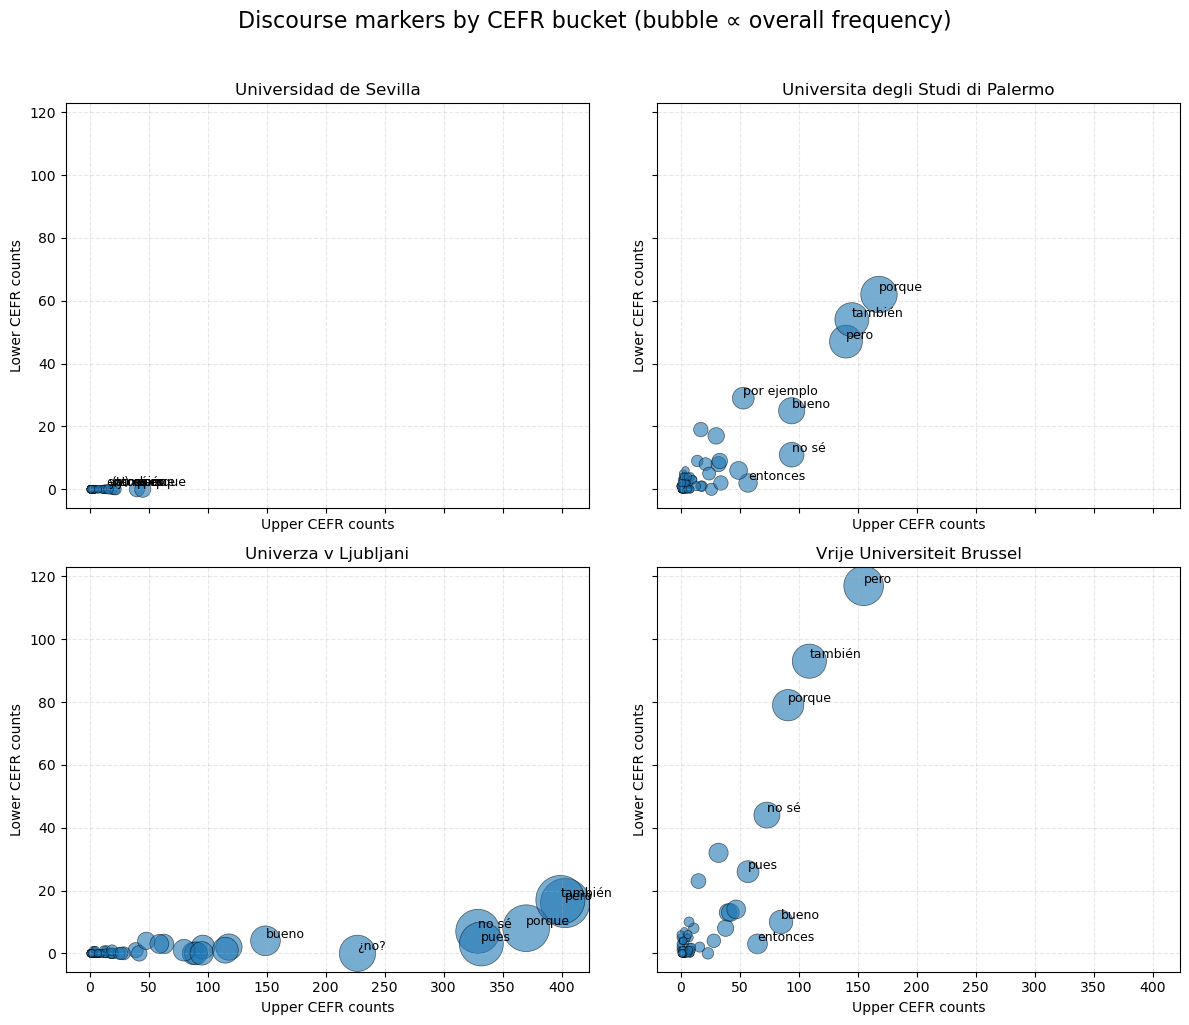

In [7]:
# collapse to upper/lower buckets per (marker, university)
acc = (marker_counts
       .groupby(["marker","university","spanish_level_bucket"], observed=True)["n"]
       .sum()
       .reset_index())

pv = (acc.pivot_table(index=["marker","university"],
                      columns="spanish_level_bucket",
                      values="n",
                      fill_value=0,
                      observed=True)
         .reset_index())
for col in ["upper","lower"]:
    if col not in pv.columns:  # in case one bucket is missing
        pv[col] = 0
pv["freq_total"] = pv["upper"] + pv["lower"]

univs = pv["university"].dropna().unique()
ncols = 2
nrows = int(np.ceil(len(univs)/ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6*ncols, 5*nrows), sharex=True, sharey=True)

for ax, uni in zip(axes.ravel(), univs):
    sub = pv.loc[pv["university"] == uni]
    ax.scatter(sub["upper"], sub["lower"], s=np.clip(sub["freq_total"], 10, None)*3, alpha=.6, linewidths=.5, edgecolors="k")
    # label top 7 by total
    for _, r in sub.nlargest(7, "freq_total").iterrows():
        ax.text(r["upper"], r["lower"], r["marker"], fontsize=9, ha="left", va="bottom")
    ax.set_title(uni)
    ax.set_xlabel("Upper CEFR counts")
    ax.set_ylabel("Lower CEFR counts")
    ax.grid(alpha=.3, linestyle="--")

fig.suptitle("Discourse markers by CEFR bucket (bubble ∝ overall frequency)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()
